# Monthly Wind‑Rose Analysis for Prampram in 2024 using NASA POWER 2m Wind Speed and Direction Data

## Name: Prince Kwesi Lassey
## Index: 35...
## Reference: 20...

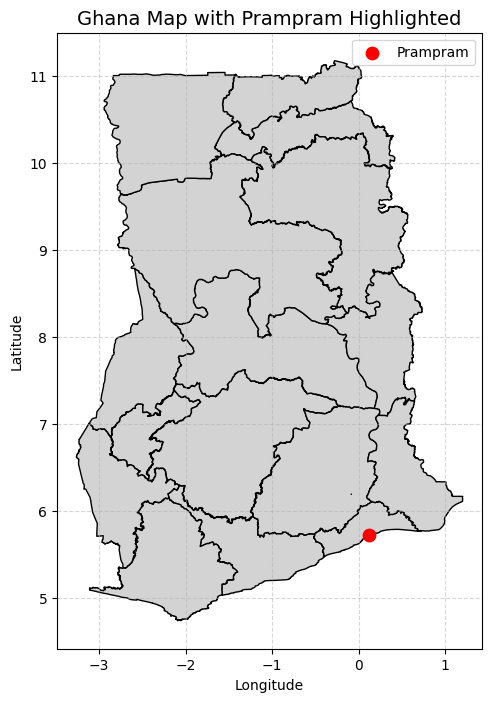

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

#load shapefile
ghana = gpd.read_file("gadm41_GHA_1.shp")

# plot the figure
fig, ax = plt.subplots(figsize=(8, 8))
ghana.plot(ax=ax, color="lightgrey", edgecolor="black")

# prampram coordinates
prampram_lat = 5.7256527566940925
prampram_lon = 0.11584993828518059

prampram = gpd.GeoDataFrame(
    {"name": ["Prampram"]},
    geometry=gpd.points_from_xy([prampram_lon], [prampram_lat]),
    crs="EPSG:4326"
)


# point with label for legend
prampram.plot(ax=ax, color="red", markersize=80, label="Prampram")


ax.set_title("Ghana Map with Prampram Highlighted", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.5)

ax.legend()

plt.show()

## Using CSV data

In [1]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for plotting
import xarray as xr # to load the netcdf file as I try to use that as well
from windrose import WindroseAxes # for creating wind rose plots
import calendar # added this to get the month names instead of expressing them as numbers

In [2]:
# had a data parsing issue with the CSV file..
# due to metadata lines before the actual data, there's the need to read the CSV manually
with open("WS2M.csv", "r", encoding="utf-8") as f:
    for i in range(20):
        print(f"{i+1}: {f.readline().rstrip()}")

1: -BEGIN HEADER-
2: NASA/POWER Source Native Resolution Daily Data
3: Dates (month/day/year): 01/01/2024 through 12/31/2024 in LST
4: Location: Regional
5: elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = na meters
6: The value for missing source data that cannot be computed or is outside of the sources availability range: -999
7: parameter(s):
8: WS2M     MERRA-2 Wind Speed at 2 Meters (m/s)
9: -END HEADER-
10: LAT,LON,YEAR,DOY,WS2M
11: 4.5,-3.125,2024,1,2.93
12: 4.5,-2.5,2024,1,2.8
13: 4.5,-1.875,2024,1,2.7
14: 4.5,-1.25,2024,1,2.98
15: 4.5,-0.625,2024,1,3.16
16: 4.5,-5.920304394294029e-13,2024,1,3.16
17: 4.5,0.625,2024,1,3.06
18: 5.0,-3.125,2024,1,2.12
19: 5.0,-2.5,2024,1,1.32
20: 5.0,-1.875,2024,1,1.3


In [3]:
# after inspecting the metadata, the actual data can be readstarting from the 10th line
windspeed = pd.read_csv("WS2M.csv", skiprows=9)
winddirection = pd.read_csv("WD2M.csv", skiprows=9)

In [4]:
# then the columns are checked to ensure the correct data is being accessed
print(windspeed.columns)
print(winddirection.columns)

Index(['LAT', 'LON', 'YEAR', 'DOY', 'WS2M'], dtype='str')
Index(['LAT', 'LON', 'YEAR', 'DOY', 'WD2M'], dtype='str')


In [6]:
# merge the datasets on common columns (LAT, LON, YEAR, DOY)
winddataframe = pd.merge(windspeed,winddirection,on=["LAT", "LON", "YEAR", "DOY"],how="inner")

# convert YEAR and DOY to a datetime format for easier analysis
winddataframe["date"] = pd.to_datetime(winddataframe["YEAR"].astype(str), format="%Y") + pd.to_timedelta(winddataframe["DOY"] - 1, unit="D")

# extract the month from the date for monthly analysis
winddataframe["month"] = winddataframe["date"].dt.month

# display the first few rows of the merged dataframe to verify the merge and date conversion
print(winddataframe.head())

   LAT    LON  YEAR  DOY  WS2M   WD2M       date  month
0  4.5 -3.125  2024    1  2.93  188.4 2024-01-01      1
1  4.5 -2.500  2024    1  2.80  192.4 2024-01-01      1
2  4.5 -1.875  2024    1  2.70  200.1 2024-01-01      1
3  4.5 -1.250  2024    1  2.98  207.8 2024-01-01      1
4  4.5 -0.625  2024    1  3.16  213.4 2024-01-01      1


In [7]:
# checking from google maps, the coordinates for Prampram are approximately:
prampram_lat = 5.7256527566940925
prampram_lon = 0.11584993828518059

# calculate the absolute difference in latitude and longitude to find the nearest grid point within the dataset
winddataframe["lat_diff"] = (winddataframe["LAT"] - prampram_lat).abs()
winddataframe["lon_diff"] = (winddataframe["LON"] - prampram_lon).abs()

# find the nearest grid point based on the smallest latitude and longitude differences
nearest_lat = winddataframe.loc[winddataframe["lat_diff"].idxmin(), "LAT"]
nearest_lon = winddataframe.loc[winddataframe["lon_diff"].idxmin(), "LON"]

# filter the dataframe to only include data from the nearest grid point
site = winddataframe[(winddataframe["LAT"] == nearest_lat) & (winddataframe["LON"] == nearest_lon)].copy()

# display the nearest grid point coordinates
print("Nearest grid point:", nearest_lat, nearest_lon)

Nearest grid point: 5.5 -5.920304394294029e-13


### Nearest grid point: Latitude 5.5 and Longitude -5.920304394294029e-13
### Longitude -5.920304394294029e-13 approches 0.0 which validates the nearest to 0.1158..

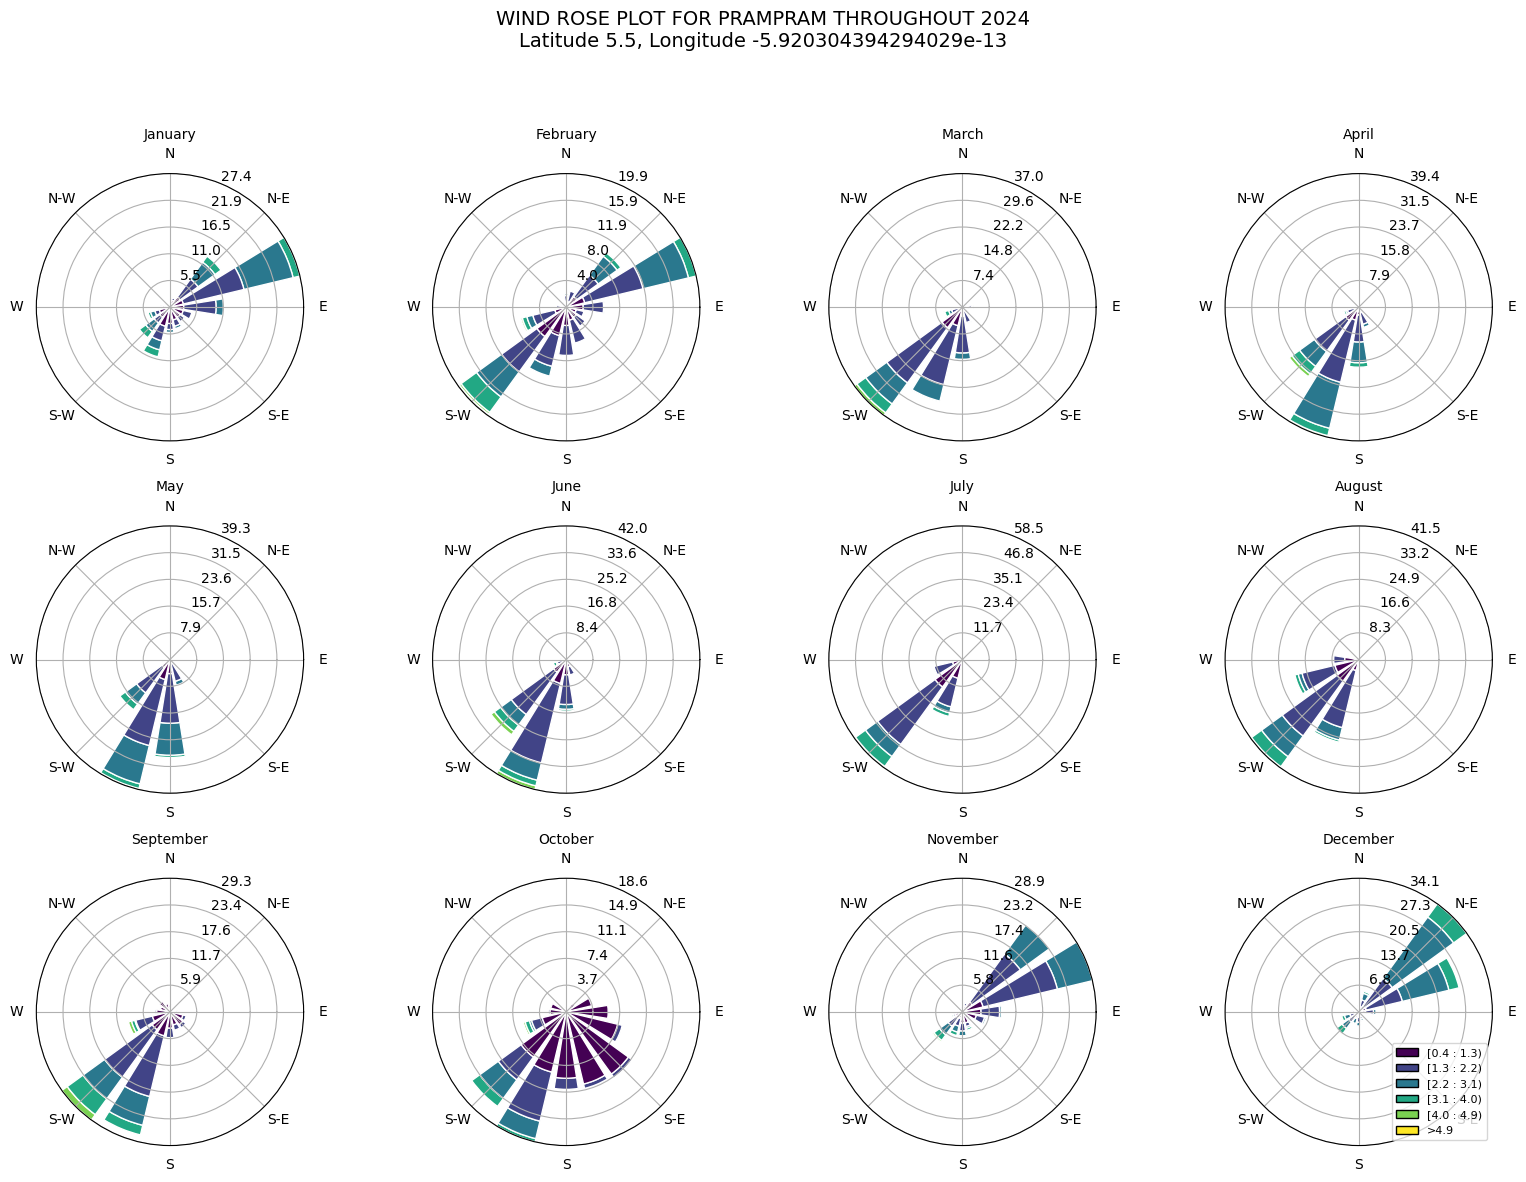

In [8]:
# created a 3x4 grid of wind rose plots for each month
fig, axes = plt.subplots(3, 4,figsize=(16, 12),subplot_kw={"projection": "windrose"})

# loop through each month and create a wind rose plot for that month
for m, ax in enumerate(axes.flatten(), start=1):
    d = winddataframe[winddataframe["month"] == m]

    ax.bar(d["WD2M"],d["WS2M"],normed=True,opening=0.8,edgecolor="white")

    ax.set_title(calendar.month_name[m], fontsize=10)

# title for thefigure
fig.suptitle(f"WIND ROSE PLOT FOR PRAMPRAM THROUGHOUT 2024\nLatitude {nearest_lat}, Longitude {nearest_lon}",fontsize=14)

# add a single legend to the last subplot
axes.flatten()[-1].legend(loc="lower right", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Using Netcdf Data

In [9]:
# loaded and combined both datasets by coordinates
wind = xr.open_mfdataset("*.nc", combine="by_coords")

In [10]:
# expanded to  take a look at the resulting dataset
wind

<xarray.Dataset> Size: 706kB
Dimensions:  (time: 366, lat: 15, lon: 8)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 120B 4.5 5.0 5.5 6.0 6.5 ... 9.5 10.0 10.5 11.0 11.5
  * lon      (lon) float64 64B -3.125 -2.5 -1.875 -1.25 ... -5.92e-13 0.625 1.25
Data variables:
    WD2M     (time, lat, lon) float64 351kB dask.array<chunksize=(366, 15, 8), meta=np.ndarray>
    WS2M     (time, lat, lon) float64 351kB dask.array<chunksize=(366, 15, 8), meta=np.ndarray>
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwide Energy Resource (POWER)
    standard_name_vocabulary:  CF Standard Name Table v72
    summary:                   The POWER project provides solar and meteorolo...
    version:                   POWER Version 10.0.0

In [11]:
# defined the coordinaates for prampram as seen on googole maps
prampram_lat = 5.7256527566940925
prampram_lon = 0.11584993828518059

# then the nearest gridpoint to pramppram in the dataset is selected
wind_point = wind.sel(lat=prampram_lat, lon=prampram_lon, method="nearest")

# taking the value of the nearest coordinates that would be used for the plot
# this coordinates would be displayed on the plot itself
nearest_lat = float(wind_point["lat"].values)
nearest_lon = float(wind_point["lon"].values)

In [12]:
# before plotting, the data has to be converted into dataframe
# showed errors when I tried to just go ahead with plotting
dataframe = pd.DataFrame({
    "date": wind_point["time"].values,
    "WS2M": wind_point["WS2M"].values,
    "WD2M": wind_point["WD2M"].values
    })

dataframe["date"] = pd.to_datetime(dataframe["date"])
dataframe["month"] = dataframe["date"].dt.month

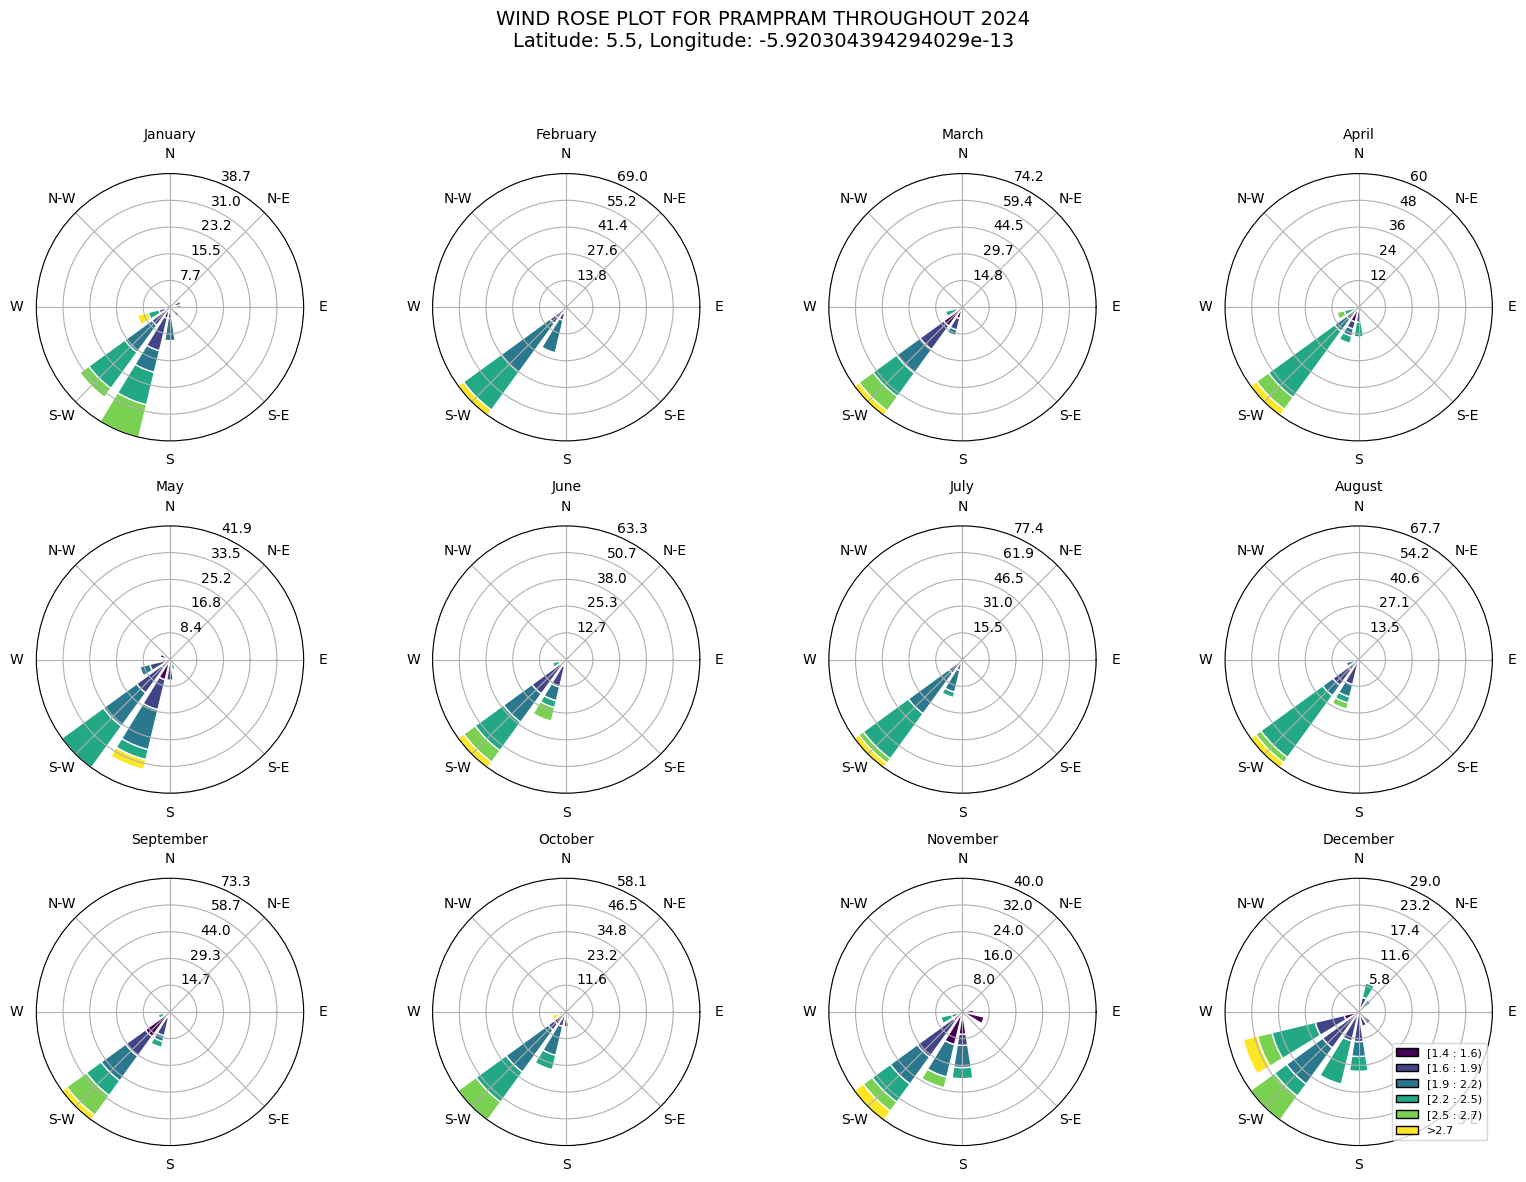

In [13]:
# created the figure.. just as was done for the figure when I used the csv
fig, axes = plt.subplots(3, 4,figsize=(16, 12),subplot_kw={"projection": "windrose"})

for m, ax in enumerate(axes.flatten(), start=1):
    d = dataframe[dataframe["month"] == m]

    ax.bar(d["WD2M"],d["WS2M"],normed=True,opening=0.8,edgecolor="white")
    ax.set_title(calendar.month_name[m], fontsize=10)

fig.suptitle(f"WIND ROSE PLOT FOR PRAMPRAM THROUGHOUT 2024\nLatitude: {nearest_lat}, Longitude: {nearest_lon}",fontsize=14)

# single legend on last subplot
axes.flatten()[-1].legend(loc="lower right", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()